#  Автоэнкодеры

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://www.eecs.qmul.ac.uk/~sgg/_ECS795P_/papers/WK07-8_PyTorch_Tutorial2.html
* https://www.youtube.com/watch?v=zp8clK9yCro
* https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f
* https://towardsdatascience.com/conditional-variational-autoencoders-with-learnable-conditional-embeddings-e22ee5359a2a
* https://pytorch.org/vision/stable/auto_examples/others/plot_visualization_utils.html#sphx-glr-auto-examples-others-plot-visualization-utils-py

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении автокодировщиков.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите набор данных MNIST из пакета `torchvision` (данный набор уже разбит на обучающее и тестовое множество).

Создайте и обучите модель автокодировщика, используя только полносвязные слои и функции активации.

Кодировщик - это функция вида
$z = f_\theta(x)$
,где $\theta$ - это параметры кодировщика.

Декодировщик - это функция вида
$\hat{x} = g_\phi(z)$
,где $\phi$ - это параметры декодировщика.

В нашем случае оба компонента представляют собой нейронные сети. Скрытое представление, полученное после части-кодировщика, должно иметь размерность 2. Последним слоем части-декодеровщика сделайте сигмоиду.

В качестве функции потерь используйте `MSELoss` между исходным и восстановленным изображением $MSE(x, \hat{x})$.

Обратите внимание, что во время обучения метки классов не используются.


- [ ] Проверено на семинаре

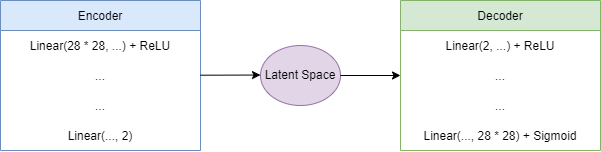

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
from torchvision.utils import make_grid
import torch.nn.functional as F

In [ ]:
tensor_transform = transforms.ToTensor()
dataset = datasets.MNIST(root='./data', train=True, transform=tensor_transform, download=True)
loader = torch.utils.data.DataLoader(dataset = dataset, batch_size=16, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [ ]:
class AutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Linear(28*28, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 36),
        nn.ReLU(),
        nn.Linear(36, 18),
        nn.ReLU(),
        nn.Linear(18, 9),
        nn.ReLU(),
        nn.Linear(9, 2)
    )
    self.decoder = nn.Sequential(
        nn.Linear(2, 9),
        nn.ReLU(),
        nn.Linear(9, 18),
        nn.ReLU(),
        nn.Linear(18, 36),
        nn.ReLU(),
        nn.Linear(36, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Sigmoid()
    )
  def forward(self, x):
    encoder = self.encoder(x)
    decoder = self.decoder(encoder)
    return decoder

In [ ]:
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1/20:   0%|          | 0/3750 [00:00<?, ?batch/s]

Epoch: 1/20, Loss: 0.04730505123734474


Epoch 2/20:   0%|          | 0/3750 [00:00<?, ?batch/s]

Epoch: 2/20, Loss: 0.044288840144872665


Epoch 3/20:   0%|          | 0/3750 [00:00<?, ?batch/s]

...

Epoch: 18/20, Loss: 0.03185531869530678


Epoch 19/20:   0%|          | 0/3750 [00:00<?, ?batch/s]

Epoch: 19/20, Loss: 0.04141855239868164


Epoch 20/20:   0%|          | 0/3750 [00:00<?, ?batch/s]

Epoch: 20/20, Loss: 0.0354803241789341


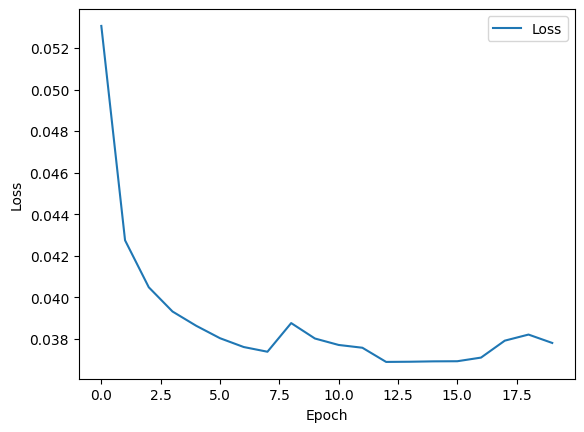

In [ ]:
num_epochs = 20
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
  epoch_loss_sum = 0.0
  n_samples = 0
  pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
  for images, _ in pbar:
    images = images.view(-1, 28*28).to(device)
    reconstructed = model(images)
    loss = criterion(reconstructed, images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    bs = images.size(0)
    epoch_loss_sum += loss.item() * bs
    n_samples += bs

  epoch_loss = epoch_loss_sum / n_samples
  losses.append(epoch_loss)
  outputs.append((epoch, images, reconstructed))
  print(f'Epoch: {epoch+1}/{num_epochs}, Loss: {loss.item()}')

plt.plot(losses, label = "Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<p class="task" id="2"></p>

2\. Получите один батч из тестового множества. Используя модель, обученную в предыдущем задании, получите скрытые представления для всех изображений из этого батча и визуализируйте на плоскости (они должны иметь размерность 2!). Раскрасьте точки в цвета, соответствующие меткам класса изображений (цифрам).

Возьмите одно изображение из тестового множества и пропустите его через обученный автокодировщик. Визуализируйте рядом (по горизонтали) два изображения: исходное и после восстановления автокодировщиком.


- [ ] Проверено на семинаре

In [ ]:
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

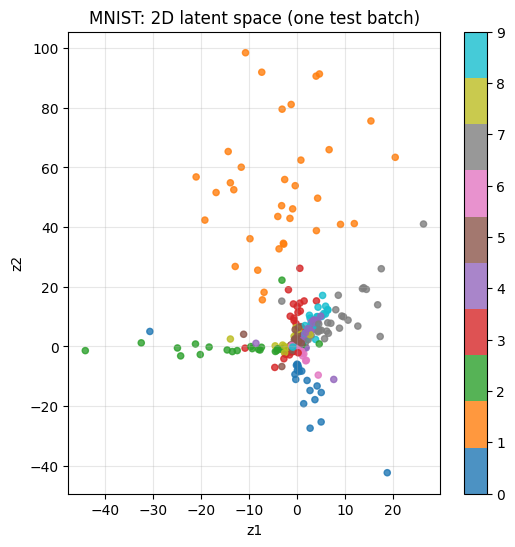

In [ ]:
model.eval()
images, labels = next(iter(test_loader))  # один батч [web:78]
images = images.view(-1, 28*28).to(device)

with torch.no_grad():
    z = model.encoder(images)

z = z.cpu().numpy()
labels = labels.numpy()

plt.figure(figsize=(6, 6))
sc = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=20, alpha=0.8)  # цвет = метка [web:85]
plt.colorbar(sc, ticks=range(10))
plt.title("MNIST: 2D latent space (one test batch)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)
plt.show()

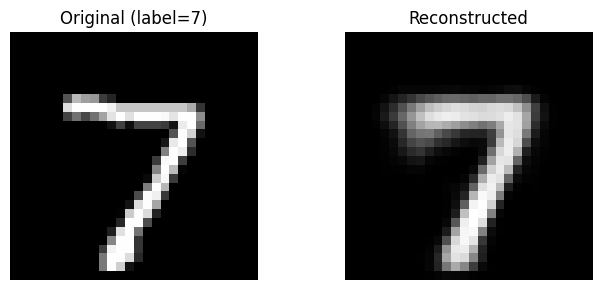

In [ ]:
img, lab = test_dataset[0]  # одно изображение из test [web:80]
x = img.view(1, 28*28).to(device)

with torch.no_grad():
    x_hat = model(x)  # реконструкция [web:83]

# обратно в 28x28
img_np = img.squeeze(0).numpy()
xhat_np = x_hat.view(28, 28).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(img_np, cmap="gray")
axes[0].set_title(f"Original (label={lab})")
axes[0].axis("off")

axes[1].imshow(xhat_np, cmap="gray")
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<p class="task" id="3"></p>

3\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения и пропускать его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

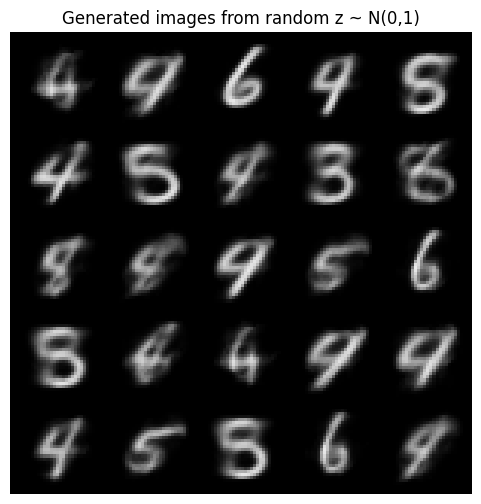

In [ ]:
def generate_from_noise(model, n = 25, device = "cpu"):
  model.eval()
  with torch.no_grad():
    z = torch.randn(n, 2).to(device)
    x_hat = model.decoder(z)
    imgs = x_hat.view(-1, 1, 28, 28)
  return imgs

gen_imgs = generate_from_noise(model, n=25, device=device)

grid = make_grid(gen_imgs.cpu(), nrow=5, padding=2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Generated images from random z ~ N(0,1)")
plt.show()

<p class="task" id="4"></p>

4\. Создайте и обучите модель условного автокодировщика, используя только полносвязные слои и функции активации.

Отличие от предыдущего варианта заключается в том, что теперь функции кодировщика и декодировщика принимают на вход также метку класса:
$$z = f_\theta(x, c)$$
$$\hat{x} = g_\phi(z, c)$$

Таким образом, теперь во теперь время обучения метки классов используются. Задействуйте их следующим образом: представьте метки классов в виде one-hot кодировки и объедините с пикселями изображения (для этого адаптируйте размерность слоев).

Скрытое представление, полученное после части-кодировщика, должно иметь размерность 2. Последним слоем части-декодеровщика сделайте сигмоиду. В качестве функции потерь используйте `MSELoss` между исходным и восстановленным изображением $MSE(x, \hat{x})$.


- [ ] Проверено на семинаре

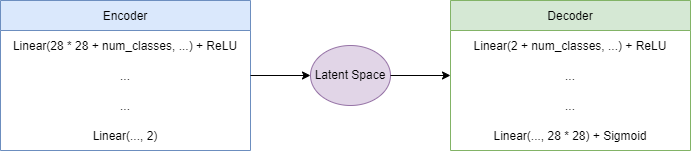

In [ ]:
tensor_transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True,  transform=tensor_transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=tensor_transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=128, shuffle=False)

In [ ]:
NUM_CLASSES = 10

class ConditionalAutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(28*28 + NUM_CLASSES, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 36),
        nn.ReLU(),
        nn.Linear(36, 18),
        nn.ReLU(),
        nn.Linear(18, 2)
    )

    self.decoder = nn.Sequential(
        nn.Linear(2 + NUM_CLASSES, 18),
        nn.ReLU(),
        nn.Linear(18, 36),
        nn.ReLU(),
        nn.Linear(36, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Sigmoid()
    )

  def forward(self, x, labels):
    labels_oh = F.one_hot(labels, num_classes=NUM_CLASSES).float().to(x.device)

    x_cond = torch.cat([x, labels_oh], dim=1)
    z = self.encoder(x_cond)

    z_cond = torch.cat([z, labels_oh], dim=1)
    x_hat = self.decoder(z_cond)
    return x_hat

In [ ]:
model = ConditionalAutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 1/20: train MSE=0.066131 | test MSE=0.049782


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 2/20: train MSE=0.046048 | test MSE=0.042444


Epoch 3/20:   0%|          | 0/469 [00:00<?, ?batch/s]

...

Epoch 18/20: train MSE=0.032862 | test MSE=0.033233


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 19/20: train MSE=0.032750 | test MSE=0.033092


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 20/20: train MSE=0.032648 | test MSE=0.033034


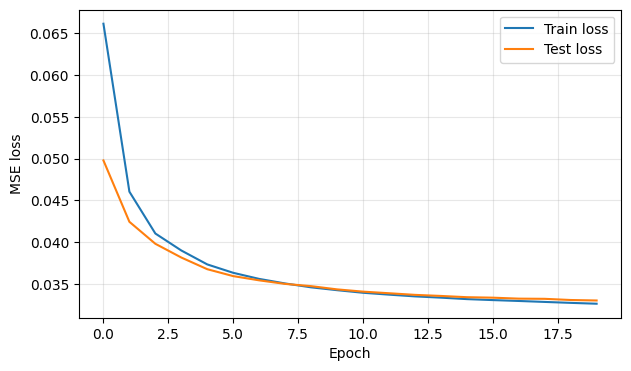

In [ ]:
num_epochs = 20
train_losses = []
test_losses = []
model = model.to(device)

for epoch in range(num_epochs):
  model.train()
  train_loss_sum, train_n = 0.0, 0

  pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
  for images, labels in pbar:
    images = images.view(-1, 28*28).to(device)
    labels = labels.to(device)

    reconstructed = model(images, labels)
    loss = criterion(reconstructed, images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    bs = images.size(0)
    train_loss_sum += loss.item() * bs
    train_n += bs

  train_epoch_loss = train_loss_sum / train_n
  train_losses.append(train_epoch_loss)

  model.eval()
  test_loss_sum = 0.0
  test_n = 0

  with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        reconstructed = model(images, labels)
        loss = criterion(reconstructed, images)

        bs = images.size(0)
        test_loss_sum += loss.item() * bs
        test_n += bs

  test_epoch_loss = test_loss_sum / test_n
  test_losses.append(test_epoch_loss)

  print(f"Epoch {epoch+1}/{num_epochs}: train MSE={train_epoch_loss:.6f} | test MSE={test_epoch_loss:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<p class="task" id="5"></p>

5\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения и one-hot представление цифры. Далее объединенный вектор пропускается его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

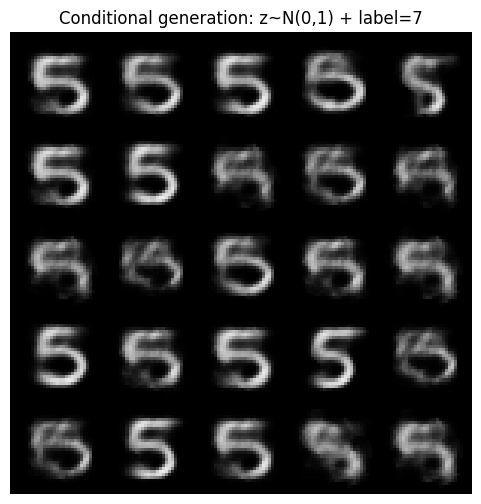

In [ ]:
NUM_CLASSES = 10

def generate_from_noise_conditional(model, n=25, digit=None, device="cpu"):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, 2, device=device)

        if digit is None:
            labels = torch.randint(0, NUM_CLASSES, (n,), device=device)   # случайные метки
        else:
            labels = torch.full((n,), int(digit), device=device, dtype=torch.long)  # все одинаковые

        labels_oh = F.one_hot(labels, num_classes=NUM_CLASSES).float()
        z_cond = torch.cat([z, labels_oh], dim=1)

        x_hat = model.decoder(z_cond)
        imgs = x_hat.view(-1, 1, 28, 28)

    return imgs, labels

gen_imgs, gen_labels = generate_from_noise_conditional(model, n=25, digit=5, device=device)

grid = make_grid(gen_imgs.cpu(), nrow=5, padding=2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Conditional generation: z~N(0,1) + label=7")
plt.show()

<p class="task" id="6"></p>

6\. Создайте и обучите модель вариационного автокодировщика, используя только полносвязные слои и функции активации.

Кодировщик - это функция следующего вида:
$$q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$$

Здесь $\phi$ - параметры кодировщика, а $\mu_\phi(x)$ и $\sigma_\phi^2(x)$ - это обучаемые функции (в нашем случае - полносвязные слои).

Чтобы иметь возможность обучить такую модель, используется т.н. reparametrization trick: на основе функций $\mu$ и $ \sigma$ считаем значение:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Декодировщик пытается восстановить исходное изображение из полученного вектора:

$$p_\theta(x|z) = f(z; \theta)$$

В качестве функции потерь обычно используется следующая:
$$\mathcal{L}_{total} = \mathcal{L}_{recon} + D_{KL}$$
$$\mathcal{L}_{recon} = -\sum_{i=1}^D [x_i \log \hat{x}_i + (1 - x_i) \log (1 - \hat{x}_i)]$$
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^J (1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2)$$


- [ ] Проверено на семинаре

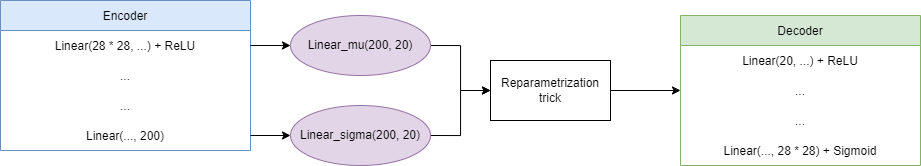

In [ ]:
class VAE(nn.Module):
  def __init__(self, latent_dim = 20, hidden_dim = 200):
    super().__init__()
    self.latent_dim = latent_dim

    self.encoder = nn.Sequential(
        nn.Linear(28*28, 400),
        nn.ReLU(),
        nn.Linear(400, hidden_dim)
    )

    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 400),
        nn.ReLU(),
        nn.Linear(400, 28*28),
        nn.Sigmoid()
    )
  def encode(self, x):
    h = self.encoder(x)
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

  def decode(self, z):
    return self.decoder(z)

  def forward(self, x):
    x = torch.flatten(x, start_dim=1)
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_hat = self.decode(z)
    return x_hat, mu, logvar

In [ ]:
def vae_loss(x_hat, x, mu, logvar):
  x = torch.flatten(x, start_dim=1)
  recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
  kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  total = recon + kld
  return total, recon, kld

In [ ]:
model = VAE(latent_dim=20, hidden_dim=200).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 20
train_losses, test_losses = [], []
train_recons, train_klds = [], []
test_recons, test_klds = [], []

for epoch in range(num_epochs):
    model.train()
    train_total_sum, train_recon_sum, train_kld_sum = 0.0, 0.0, 0.0
    train_n = 0

    pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{num_epochs}", unit="batch")
    for images, _ in pbar:
        images = images.to(device)

        x_hat, mu, logvar = model(images)
        loss, recon, kld = vae_loss(x_hat, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        train_total_sum += loss.item()
        train_recon_sum += recon.item()
        train_kld_sum += kld.item()
        train_n += bs

    train_total = train_total_sum / train_n
    train_recon = train_recon_sum / train_n
    train_kld = train_kld_sum / train_n

    train_losses.append(train_total)
    train_recons.append(train_recon)
    train_klds.append(train_kld)

    model.eval()
    test_total_sum, test_recon_sum, test_kld_sum = 0.0, 0.0, 0.0
    test_n = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            x_hat, mu, logvar = model(images)
            loss, recon, kld = vae_loss(x_hat, images, mu, logvar)

            bs = images.size(0)
            test_total_sum += loss.item()
            test_recon_sum += recon.item()
            test_kld_sum += kld.item()
            test_n += bs

    test_total = test_total_sum / test_n
    test_recon = test_recon_sum / test_n
    test_kld = test_kld_sum / test_n

    test_losses.append(test_total)
    test_recons.append(test_recon)
    test_klds.append(test_kld)

    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"train total={train_total:.3f} (recon={train_recon:.3f}, kld={train_kld:.3f}) | "
        f"test total={test_total:.3f} (recon={test_recon:.3f}, kld={test_kld:.3f})"
    )


Train 1/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 1/20: train total=175.909 (recon=167.101, kld=8.808) | test total=138.526 (recon=123.448, kld=15.078)


Train 2/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 2/20: train total=127.730 (recon=111.599, kld=16.131) | test total=119.421 (recon=101.836, kld=17.585)


Train 3/20:   0%|          | 0/469 [00:00<?, ?batch/s]

...

Epoch 18/20: train total=101.216 (recon=80.366, kld=20.850) | test total=101.345 (recon=80.448, kld=20.897)


Train 19/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 19/20: train total=100.986 (recon=80.091, kld=20.896) | test total=101.081 (recon=80.362, kld=20.719)


Train 20/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 20/20: train total=100.811 (recon=79.879, kld=20.932) | test total=101.194 (recon=80.194, kld=21.000)


<p class="task" id="7"></p>

7\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения. Далее вектор пропускается его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

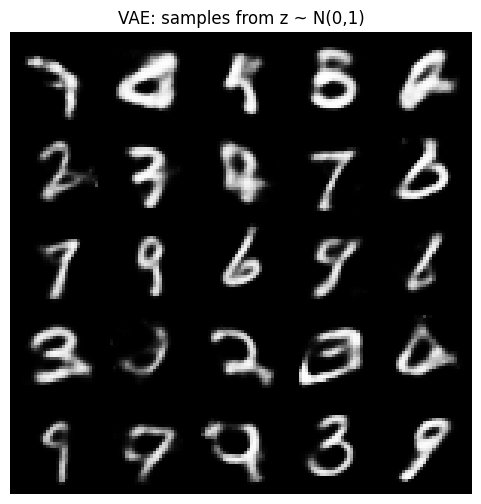

In [ ]:
def generate_from_noise_vae(model, n=25, device="cpu"):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim, device=device)
        x_hat = model.decode(z)
        imgs = x_hat.view(-1, 1, 28, 28)

    return imgs

gen_imgs = generate_from_noise_vae(model, n=25, device=device)

grid = make_grid(gen_imgs.cpu(), nrow=5, padding=2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("VAE: samples from z ~ N(0,1)")
plt.show()
